In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
# from torchvision.transforms import v2 as transforms

import numpy as np

import matplotlib.pyplot as plt

from torchsummary import summary

from tqdm import tqdm

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [4]:
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

num_classes = 10
batch_size  = 128
num_workers = 2

# CIFAR10 mean and standard deviation
mean = (0.49139968, 0.48215827, 0.44653124)
std  = (0.24703233, 0.24348505, 0.26158768)

# apporximate mean and standard deviation
mean = (0.5, 0.5, 0.5)
std  = (0.5, 0.5, 0.5)

In [5]:
class DownloadData():
    def __init__(self, classes, mean, std):
        super(DownloadData, self).__init__()

        self.classes = classes
        self.mean    = mean
        self.std     = std

        self.transform_train = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(self.mean, self.std)
        ])
        self.transform_test  = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(self.mean, self.std)
        ])

    def download_data(self):
        train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=self.transform_train)
        test_data  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=self.transform_test)

        self.train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
        self.test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

        return self.train_loader, self.test_loader

    # def add_augmentation(self):
    #     cutmix          = self.transforms.CutMix(num_classes=len(classes))
    #     mixup           = self.transforms.MixUp(num_classes=len(classes))
    #     cutmix_or_mixup = self.transforms.RandomChoice([cutmix, mixup])

    def shape(self):
        self.X, self.y = next(iter(self.train_loader))
        return (f'Shape of X: {self.X.size()} \nShape of y: {self.y.size()}')

    def show_images(self):
        for i in range(3):
            print(f'\nImage {i} ({self.classes[int(self.y[i])]}):\n')

            image = self.X[i].numpy().transpose(1, 2, 0)  # (C, H, W) → (H, W, C)

            mean  = np.array(self.mean)
            std   = np.array(self.std)
            image = std * image + mean    # Unnormalize
            image = np.clip(image, 0, 1)  # Clip values to [0, 1]

            plt.figure(figsize=(1, 1))
            plt.imshow(image)
            plt.axis('off')
            plt.show()

In [6]:
data = DownloadData(classes, mean, std)
train_loader, test_loader = data.download_data()

100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


Shape of X: torch.Size([128, 3, 32, 32]) 
Shape of y: torch.Size([128])

Image 0 (bird):



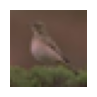


Image 1 (truck):



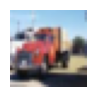


Image 2 (automobile):



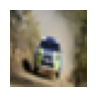

In [7]:
data_shape = data.shape()
print(data_shape)

data.show_images()

In [ ]:
# channel wise attention
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        batch, in_channels, H, W = x.shape

        # Squeeze: Global Average Pooling over spatial dimensions
        m = torch.mean(x, dim=(2,3))      # shape: (batch, in_channels)

        # Excitation: Fully connected layers to get channel attention
        a = self.fc(m)                    # shape: (batch, num_conv)
        a = a.unsqueeze(-1).unsqueeze(-1) # shape: (batch, num_conv, 1, 1)

        attention = x * a

        return attention

In [ ]:
# spatial attention
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Compute average and max across channels
        avg_out    = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        x_out = self.conv(x_cat)
        attn_map  = self.sigmoid(x_out)

        attention = x * attn_map

        return attention

In [ ]:
class IntermediateBlock(nn.Module):
    def __init__(self, in_channels, conv_configs, kernel_size=3, padding=1, stride=1,
                 use_skip=False, skip_channels=None, use_se=False, se_reduction=16, use_spatial=False):
        super(IntermediateBlock, self).__init__()

        self.use_skip    = use_skip
        self.use_se      = use_se
        self.use_spatial = use_spatial

        self.convs   = []

        num_conv     = len(conv_configs)
        out_channels = conv_configs[0]['out_channels']

        # convolutional layers
        for config in conv_configs:
            kernel   = config.get('kernel_size', kernel_size)
            padding  = config.get('padding', padding)
            stride   = config.get('stride', stride)

            conv     = nn.Conv2d(in_channels, out_channels, kernel_size=kernel, stride=stride, padding=padding)
            self.convs.append(conv)

        self.convs = nn.ModuleList(self.convs)

        # self.relu  = nn.ReLU()
        self.relu  = nn.LeakyReLU()

        # self.maxpool = nn.MaxPool2d(3, stride=None, padding=1)
        # self.avgpool = nn.AvgPool2d(3, stride=None, padding=1)

        self.fc    = nn.Linear(in_channels, num_conv)
        self.bn    = nn.BatchNorm2d(out_channels)
        self.drop  = nn.Dropout(p=0.3)

        if self.use_skip:
            if skip_channels is None:
                skip_channels = out_channels
            self.skip_conv = nn.Conv2d(in_channels, skip_channels, kernel_size=1, stride=1, padding=0) # 1x1 conv

        if self.use_se:
            self.se = SEBlock(out_channels, reduction=se_reduction)

        if self.use_spatial:
            self.spatial_attn = SpatialAttention()

    def forward(self, x):
        batch, in_channels, H, W = x.shape

        m = torch.mean(x, dim=(2,3)) # shape: (batch, in_channels)
        a = self.fc(m)               # shape: (batch, num_conv)
        a = torch.softmax(a, dim=1)

        conv_outputs = []
        for conv in self.convs:
            out = conv(x)
            out = self.relu(out)
            conv_outputs.append(out)

        a = a.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)  # shape: (batch, num_conv, 1, 1, 1)
        conv_stack = torch.stack(conv_outputs, dim=1)    # shape: (batch, num_conv, out_channels, H, W)
        out = (a * conv_stack).sum(dim=1)                # shape: (batch, out_channels, H, W)

        if self.use_spatial:
            out = self.spatial_attn(out)

        if self.use_se:
            out = self.se(out)

        if self.use_skip:
            skip = self.skip_conv(x)  # shape: (batch, out_channels, H, W)
            out = out + skip

        out = self.bn(out)
        out = self.drop(out)

        return out

In [11]:
class OutputBlock(nn.Module):
    def __init__(self, in_channels, num_classes=10, fc_hidden_dims=[]):
        super(OutputBlock, self).__init__()

        layers = []

        for h_dim in fc_hidden_dims:
            layers.append(nn.Linear(in_channels, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=0.3))
            in_channels = h_dim

        layers.append(nn.Linear(in_channels, 10))
        self.fc_layers  = nn.Sequential(*layers)

    def forward(self, x):
        m = x.mean(dim=(2, 3)) # shape: (batch, in_channels)
        o = self.fc_layers(m)  # shape: (last_hidden_dim, num_classes)

        return o


In [12]:
class ClassificationModel(nn.Module):
    def __init__(self, conv_configs_dict, use_se_attn, use_sp_attn,
                 in_channels=3, num_classes=10,
                 fc_hidden_dims=[], use_skip_conn=[]):
        super(ClassificationModel, self).__init__()

        self.blocks = nn.ModuleList()

        for n_block, key in enumerate(conv_configs_dict):
            conv_configs = conv_configs_dict[key]

            skip    = use_skip_conn[n_block]
            se_attn = use_se_attn[n_block]
            sp_attn = use_sp_attn[n_block]

            block = IntermediateBlock(in_channels=in_channels,
                                      conv_configs=conv_configs,
                                      use_skip=skip,
                                      use_se=se_attn,
                                      use_spatial=sp_attn)
            self.blocks.append(block)

            # Update in_channels for the next block
            in_channels = conv_configs[-1]['out_channels']

        self.output_block = OutputBlock(in_channels=in_channels,
                                        num_classes=num_classes,
                                        fc_hidden_dims=fc_hidden_dims)

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return self.output_block(x)

In [13]:
conv_configs_dict = {
#     'config1': [
#     {'out_channels': 16, 'kernel_size': 3, 'padding': 1},
#     {'out_channels': 16, 'kernel_size': 3, 'padding': 1},
# ],
#     'config2': [
#     {'out_channels': 32, 'kernel_size': 3, 'padding': 1},
#     {'out_channels': 32, 'kernel_size': 3, 'padding': 1},
# ],
    'config3': [
    {'out_channels': 64, 'kernel_size': 3, 'padding': 1},
    {'out_channels': 64, 'kernel_size': 3, 'padding': 1},
],
    'config4': [
    {'out_channels': 128, 'kernel_size': 3, 'padding': 1},
    {'out_channels': 128, 'kernel_size': 3, 'padding': 1},
],
    'config5': [
    {'out_channels': 256, 'kernel_size': 3, 'padding': 1},
    {'out_channels': 256, 'kernel_size': 3, 'padding': 1},
],
    'config6': [
    {'out_channels': 512, 'kernel_size': 3, 'padding': 1},
    {'out_channels': 512, 'kernel_size': 3, 'padding': 1},
],
}

use_skip_conn = [
    # False,       # B1
    # False,       # B2
    False,        # B3
    False,        # B4
    False,        # B5
    False,        # B6
]

use_se_attn = [
    # False,       # B1
    # False,       # B2
    False,        # B3
    False,        # B4
    False,        # B5
    False,        # B6
]

use_sp_attn = [
    # False,       # B1
    # False,       # B2
    False,        # B3
    False,        # B4
    False,        # B5
    False,        # B6
]

fc_hidden_dims = [128, 64]

In [14]:
def init_weights(m):
    if type(m) == nn.Linear or type(m) == nn.Conv2d:
        nn.init.xavier_uniform_(m.weight)

model = ClassificationModel(
                            conv_configs_dict,
                            fc_hidden_dims = fc_hidden_dims,
                            use_skip_conn  = use_skip_conn,
                            use_se_attn    = use_se_attn,
                            use_sp_attn    = use_sp_attn
                           ).to(device)
model.apply(init_weights)

print(model)

ClassificationModel(
  (blocks): ModuleList(
    (0): IntermediateBlock(
      (convs): ModuleList(
        (0-1): 2 x Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (relu): LeakyReLU(negative_slope=0.01)
      (fc): Linear(in_features=3, out_features=2, bias=True)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop): Dropout(p=0.3, inplace=False)
    )
    (1): IntermediateBlock(
      (convs): ModuleList(
        (0-1): 2 x Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (relu): LeakyReLU(negative_slope=0.01)
      (fc): Linear(in_features=64, out_features=2, bias=True)
      (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop): Dropout(p=0.3, inplace=False)
    )
    (2): IntermediateBlock(
      (convs): ModuleList(
        (0-1): 2 x Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (relu

In [15]:
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [-1, 2]               8
            Conv2d-2           [-1, 64, 32, 32]           1,792
         LeakyReLU-3           [-1, 64, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]           1,792
         LeakyReLU-5           [-1, 64, 32, 32]               0
       BatchNorm2d-6           [-1, 64, 32, 32]             128
           Dropout-7           [-1, 64, 32, 32]               0
 IntermediateBlock-8           [-1, 64, 32, 32]               0
            Linear-9                    [-1, 2]             130
           Conv2d-10          [-1, 128, 32, 32]          73,856
        LeakyReLU-11          [-1, 128, 32, 32]               0
           Conv2d-12          [-1, 128, 32, 32]          73,856
        LeakyReLU-13          [-1, 128, 32, 32]               0
      BatchNorm2d-14          [-1, 128,

In [16]:
lr = 0.001
weight_decay = 0.01
label_smoothing=0.1

criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

In [17]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=10):
    train_loss_per_batch = []
    train_losses         = []
    train_accuracies     = []
    val_accuracies       = []
    val_losses           = []

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

    for epoch in range(num_epochs):
        total_correct = 0
        total_samples = 0
        running_loss  = 0.0

        model.train()
        for inputs, targets in tqdm(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)

            logits  = model(inputs)
            loss    = criterion(logits, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss_per_batch.append(float(loss.item()))

            running_loss  += loss.item()
            total_correct += (logits.argmax(dim=1) == targets).sum().item()
            total_samples += len(targets)

        epoch_loss = running_loss / len(train_loader)
        epoch_acc  = 100. * total_correct / total_samples
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # Validation (Test set used as validation)
        val_loss, val_acc = evaluate_model(model, test_loader, criterion, silent=True)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        scheduler.step()

        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

    return train_loss_per_batch, train_losses, train_accuracies, val_losses, val_accuracies

In [18]:
def evaluate_model(model, test_loader, criterion, silent=False):
    test_loss     = 0.0
    avg_loss      = 0.0
    total_correct = 0
    total_samples = 0

    model.eval()
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            logits  = model(inputs)
            loss    = criterion(logits, targets)

            test_loss     += loss.item()
            total_correct += (logits.argmax(dim=1) == targets).sum().item()
            total_samples += len(targets)

        avg_loss = test_loss / len(test_loader)
        accuracy = 100. * total_correct / total_samples
        if not silent:
            print(f'Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.2f}%')
        return avg_loss, accuracy

In [19]:
# Training the model
num_epochs = 50

train_loss_per_batch, train_losses, train_accuracies, val_losses, val_accuracies = train_model(
    model, train_loader, test_loader, criterion, optimizer, num_epochs=num_epochs)

100%|██████████| 391/391 [02:30<00:00,  2.60it/s]


Epoch 1/50, Train Loss: 1.8498, Train Acc: 37.00%, Val Loss: 1.6033, Val Acc: 48.89%


100%|██████████| 391/391 [02:31<00:00,  2.59it/s]


Epoch 2/50, Train Loss: 1.5706, Train Acc: 52.12%, Val Loss: 1.4294, Val Acc: 58.02%


100%|██████████| 391/391 [02:31<00:00,  2.57it/s]


...

Epoch 48/50, Train Loss: 0.6052, Train Acc: 97.52%, Val Loss: 0.7924, Val Acc: 88.55%


100%|██████████| 391/391 [02:31<00:00,  2.58it/s]


Epoch 49/50, Train Loss: 0.6038, Train Acc: 97.67%, Val Loss: 0.7932, Val Acc: 88.44%


100%|██████████| 391/391 [02:31<00:00,  2.58it/s]


Epoch 50/50, Train Loss: 0.6036, Train Acc: 97.63%, Val Loss: 0.7920, Val Acc: 88.47%


In [20]:
# Testing the model
test_loss, test_accuracy = evaluate_model(model, test_loader, criterion)

Test Loss: 0.7920, Test Accuracy: 88.47%


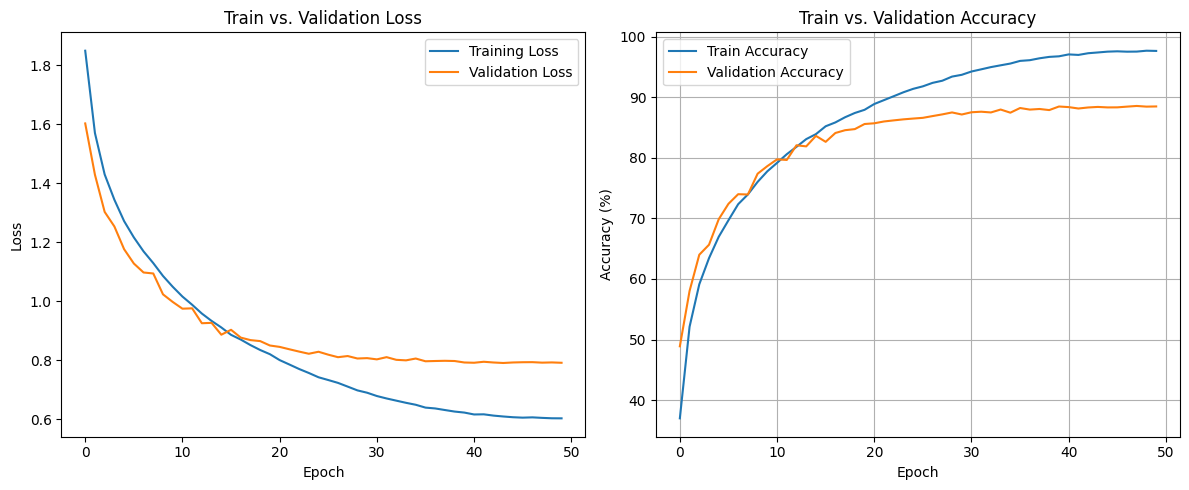

In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Train vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train vs. Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

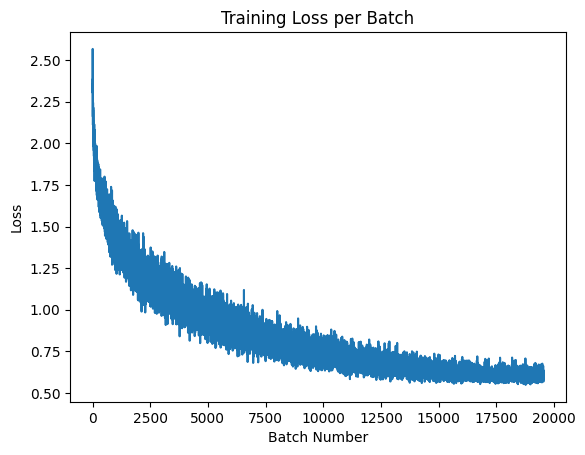

In [22]:
# Plots the loss for each training batch
plt.plot(train_loss_per_batch)
plt.title('Training Loss per Batch')
plt.xlabel('Batch Number')
plt.ylabel('Loss')
plt.show()